In [8]:
from typing import TypedDict, NotRequired
from langgraph.graph import StateGraph, START, END

In [9]:
class AgentState(TypedDict):
    number1: int
    number2: int
    num3: int
    num4: int
    op: str
    op2: str
    final1: int
    final2: int

In [10]:
def adder(state: AgentState) -> AgentState:
    """number1 op number2 -> final1 (addition)"""
    state['final1'] = state['number1'] + state['number2']
    return state


def subtractor(state: AgentState) -> AgentState:
    """number1 op number2 -> final1 (subtraction)"""
    state['final1'] = state['number1'] - state['number2']
    return state


def adder2(state: AgentState) -> AgentState:
    """num3 op2 num4 -> final2 (addition)"""
    state['final2'] = state['num3'] + state['num4']
    return state


def subtractor2(state: AgentState) -> AgentState:
    """num3 op2 num4 -> final2 (subtraction)"""
    state['final2'] = state['num3'] - state['num4']
    return state


def decider(state: AgentState) -> str:
    """Decides first branch based on op (number1 op number2)."""
    if state['op'] == '+':
        return "addition_op"
    else:
        return "subtractor_op"


def decider2(state: AgentState) -> str:
    """Decides second branch based on op2 (num3 op2 num4)."""
    if state['op2'] == '+':
        return "addition_op"
    else:
        return "subtractor_op"


In [11]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder)
graph.add_node("subtractor", subtractor)
graph.add_node("router", lambda state: state) #passthrough function
graph.add_node("router2", lambda state: state)
graph.add_node("adder2", adder2)
graph.add_node("subtractor2", subtractor2)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decider,
    {
        "addition_op": "adder",
        "subtractor_op": "subtractor",
    },
)

graph.add_edge("adder", "router2")
graph.add_edge("subtractor", "router2")
graph.add_conditional_edges(
    "router2",
    decider2,
    {
        "addition_op": "adder2",
        "subtractor_op": "subtractor2",
    },
)

graph.add_edge("adder2", END)
graph.add_edge("subtractor2", END)


app = graph.compile()

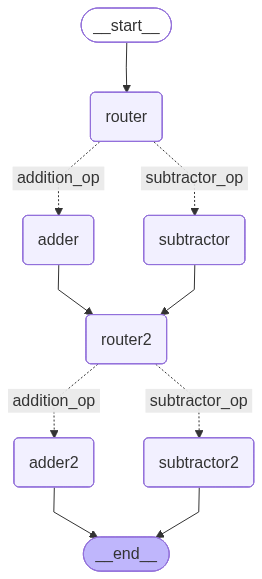

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result = app.invoke({"number1": 10, "number2": 9,"num3": 10, "num4": 9, "op": "-", "op2": "+"})
print(result)
print(result['final1'])
print(result['final2'])

{'number1': 10, 'number2': 9, 'num3': 10, 'num4': 9, 'op': '-', 'op2': '+', 'final1': 1, 'final2': 19}
1
19


In [17]:
result2 = app.invoke({"number1": 7, "number2": 3, "num3": 5, "num4": 3, "op": "+", "op2": "+"})
print(result2)
print(result2['final1'])
print(result2['final2'])

{'number1': 7, 'number2': 3, 'num3': 5, 'num4': 3, 'op': '+', 'op2': '+', 'final1': 10, 'final2': 8}
10
8
